# Task 2 - Data Pipeline
MNSIT is a massive data collection of 60,000 images, feeding one image at a time into the model is very slow therefore we use a Data Pipeline.

A Data pipeline groups single images into packets, scrambles the order and delivers it to the CPU/GPU.

THE Dataset
The total number of images in the dataset is 60000
Single image shape: torch.Size([1, 28, 28])
Associated target label: 2


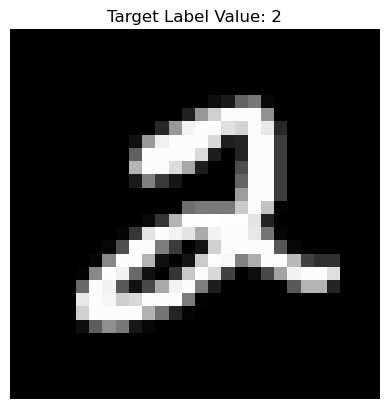

In [1]:
#Copying all the code from task 1 to move forward

import torch
import torchvision  #lib for computer vision in pytorch ecosystem
from torchvision.transforms import Compose, ToTensor, Normalize
import matplotlib.pyplot as plt 
#To transform the raw images (in png format) to tensors format we make us of the following:

transformy =Compose([
    ToTensor(), # it also scales the pixel values from [0,255] to [0,1] by dividing each value by 255
    
    #We normalize the pixel values further to center the data around 0 to help with the math.
    # The mean for the MNSIT dataset is 0.1307 and std dev is 0.3081 so we nromalize around these two using ((x-0.1307)/0.3081)
    Normalize((0.1307,),(0.3081,))
])

#downloading the dataset - both the training one and test one and applying transform on each image
train_dataset=torchvision.datasets.MNIST(
    root='./data',
    train = True,
    download=True,
    transform=transformy
)

test_dataset=torchvision.datasets.MNIST(
    root='./data',
    train= False,
    download=True,
    transform=transformy
)
print("THE Dataset")
print(f"The total number of images in the dataset is {len(train_dataset)}")
#The Mnsit dataset is in form of tuple pairs of the (image,itslabel integer)

single_image, single_label= train_dataset[5] #by changing the index we can access different images and look at their shapes 
print(f"Single image shape: {single_image.shape}")
print(f"Associated target label: {single_label}")
#Using matplotlib to render the images 
plt.imshow(single_image.squeeze(), cmap='gray') #squeeze changes the shape from [1,28,28] to [28,28] so that matplotlib can understand
plt.title(f"Target Label Value: {single_label}")
plt.axis('off')#disables the axes
plt.show()# final output

In [2]:
# A Dataloader is something that wraps an iterable about the dataset and helps in easier access to the data items.
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader=DataLoader(dataset=test_dataset,batch_size=64, shuffle=False)
#Batch size=64 meaning 64 similar images are grouped together into a batch , shuffling the training dataset is important so that it doesnt memorize the sequence.


In [3]:
# To iterate through the dataloader we convert it into a python iterator using iter(), next() grabs each batch 
image_batch, label_batch = next(iter(train_loader))
# features of the batch
print(f"Batch of images shape: {image_batch.shape}") #[batch size, channel, height, width]
print(f"Batch of labels shape: {label_batch.shape}")

Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


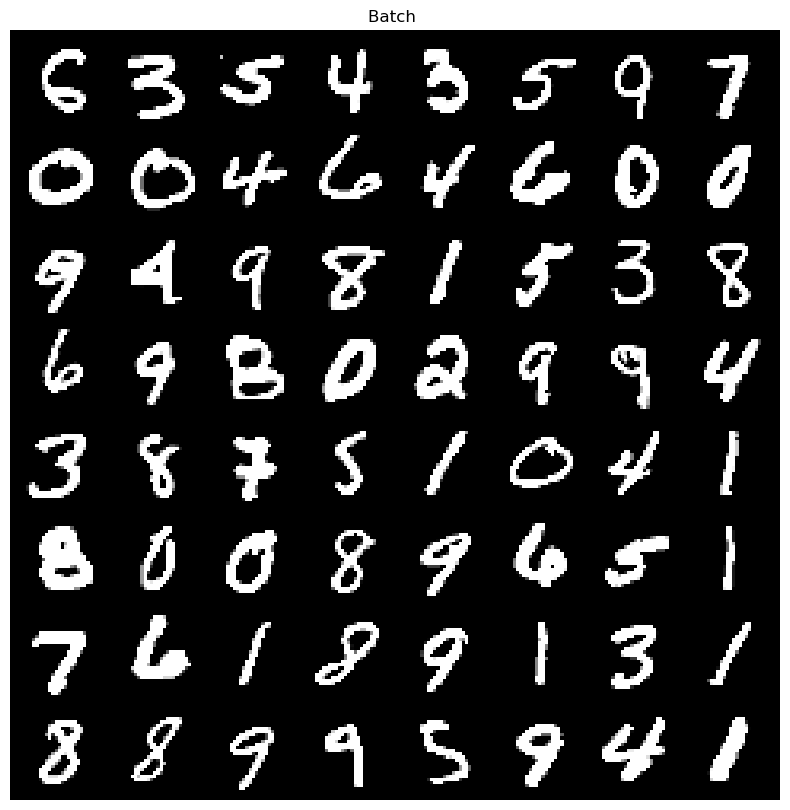

In [5]:
#rendering a batch by making a grid in pytorch and then converting it to matplotlib's layout using .permute()
grid_tensor = torchvision.utils.make_grid(image_batch, nrow=8, padding=2)
grid_np = grid_tensor.permute(1, 2, 0).numpy()# by pytorch [C-0,H-1,W-2] --> by matplotlob [H,W,C] so(1,2,0)
plt.figure(figsize=(10, 10))
plt.imshow(grid_np)
plt.title("Batch ")
plt.axis('off')
plt.show()